## 1. Tải dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tải dữ liệu Iris
df = sns.load_dataset("iris")
print (df.head ())
print (df.shape)
print (df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


## 2 Phần 1 — Thống kê mô tả & đặc trưng

### 2.1 - Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.

In [23]:
display(df.head())

print("Số dòng, số cột:", df.shape)
print("\nKiểu dữ liệu của từng cột:")
print(df.dtypes)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Số dòng, số cột: (150, 5)

Kiểu dữ liệu của từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


**Nhận xét:** Dữ liệu gồm 150 dòng và 5 cột. Bốn cột đầu (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) là kiểu số thực, cột cuối (`species`) là kiểu chuỗi.

### 2.2 - Với mỗi **biến số**, tính: `mean`, `median`, `mode`, `var`, `std`, `min`, `max`, `Q1`, `Q3` và `IQR`.

In [24]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

stats_df = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'mode': df[numeric_cols].mode().iloc[0],
    'var': df[numeric_cols].var(),
    'std': df[numeric_cols].std(),
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max(),
    'Q1': df[numeric_cols].quantile(0.25),
    'Q3': df[numeric_cols].quantile(0.75)
})

stats_df['IQR'] = stats_df['Q3'] - stats_df['Q1']
display(stats_df)

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


**Nhận xét:** Bảng trên thể hiện đầy đủ các đặc trưng thống kê mô tả cho 4 biến số, giúp ta thấy được sự phân tán, trung bình, cũng như các khoảng tứ phân vị của từng biến.

### 2.3 - Theo **từng nhóm** (loài `species`): dùng `groupby` tính `mean` và `std` của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.

In [25]:
grouped_stats = df.groupby('species')[numeric_cols].agg(['mean', 'std'])
display(grouped_stats)

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

**Nhận xét:**
- Nhóm **`setosa`** là nhóm có sự khác biệt rõ rệt nhất so với hai nhóm còn lại (`versicolor` và `virginica`).
- Cụ thể, giá trị trung bình (`mean`) của các đặc trưng **`petal_length`** và **`petal_width`** ở loài `setosa` nhỏ hơn rất nhiều và tách biệt hoàn toàn so với hai loài kia.

## 3 — Phân phối xác suất

### 3.1 - Vẽ **histogram** + **KDE** cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?

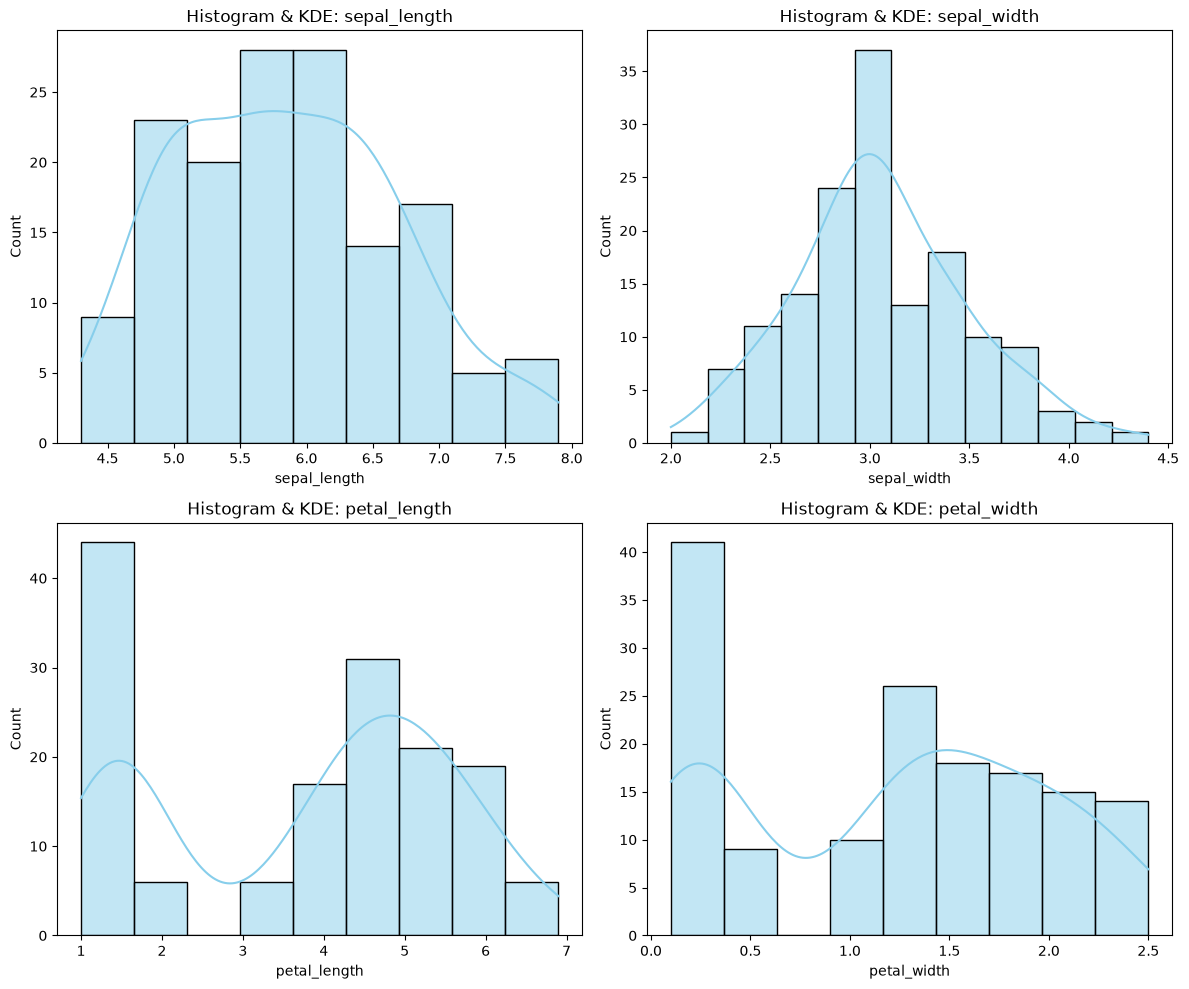

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Histogram & KDE: {col}')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **`sepal_width`**: Hình dạng phân phối dạng chuông đối xứng, rất gần với phân phối chuẩn.
- **`sepal_length`**: Gần phân phối chuẩn nhưng có xu hướng hơi lệch phải một chút.
- **`petal_length`** và **`petal_width`**: Có hình dạng phân phối nhiều đỉnh, tách biệt rõ ràng thành hai cụm dữ liệu (một cụm giá trị nhỏ, một cụm giá trị lớn).

### 3.2 - Vẽ **boxplot** từng biến theo nhóm (`species`) để so sánh phân phối giữa các loài.

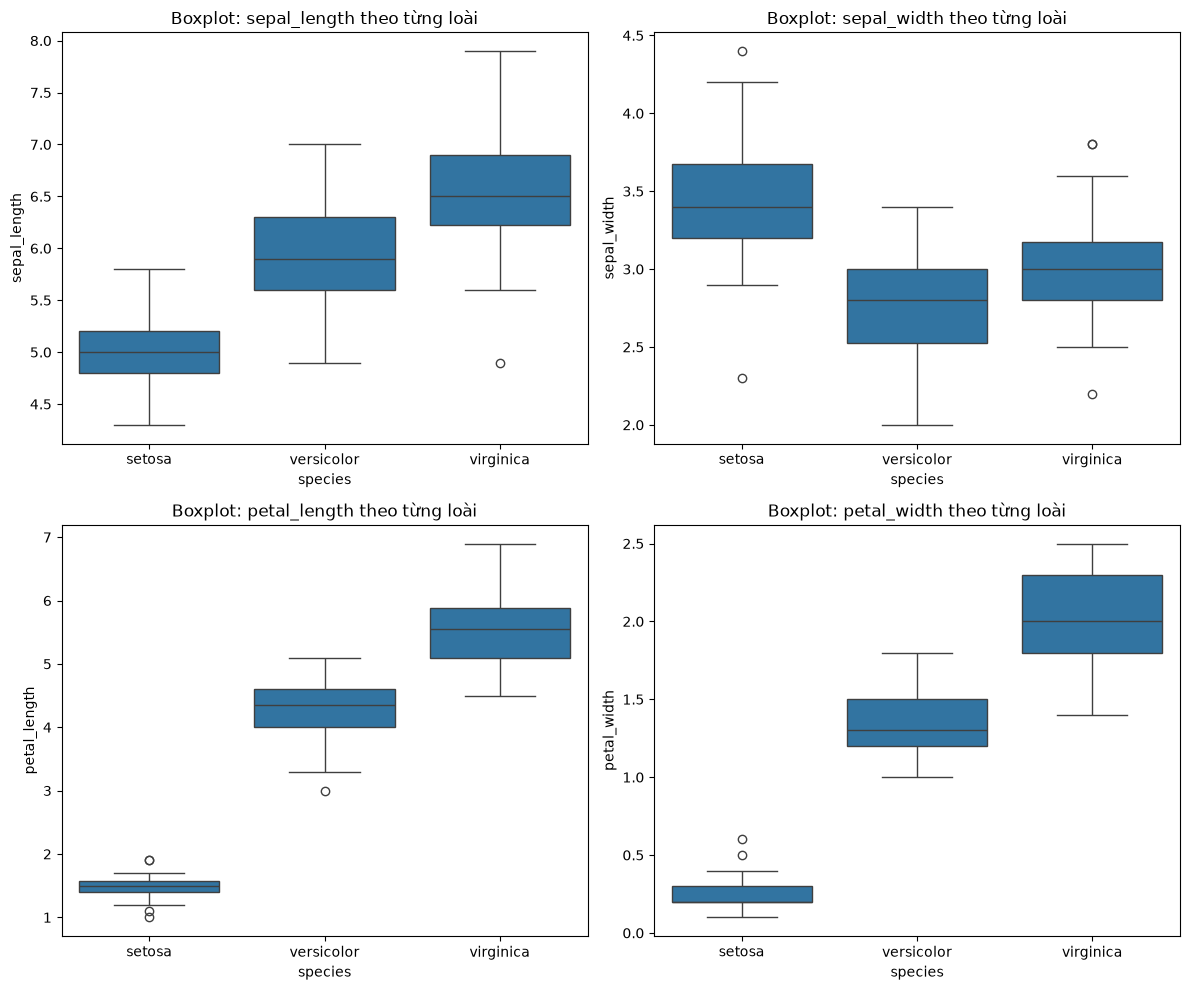

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot: {col} theo từng loài')

plt.tight_layout()
plt.show()

**Nhận xét:**
- Boxplot cho thấy sự khác biệt rất lớn về mặt phân phối của loài `setosa` so với hai loài còn lại đối với 2 biến `petal_length` và `petal_width` (hoàn toàn không có sự giao thoa, khoảng IQR tách biệt hoàn toàn).
- Các loài `versicolor` và `virginica` đôi khi xuất hiện các giá trị outliers được biểu diễn bằng các dấu chấm whiskers của hộp.
- Ở các biến `sepal`, các khoảng phân bố của các loài có sự chồng chéo nhiều hơn.

### 3.3 - **Mô phỏng**: chọn một biến, sinh mẫu từ phân phối **Normal** có cùng `mean` và `std` bằng `np.random.normal`; vẽ chồng histogram dữ liệu thực tế với đường **PDF lý thuyết**. Nhận xét mức độ khớp.

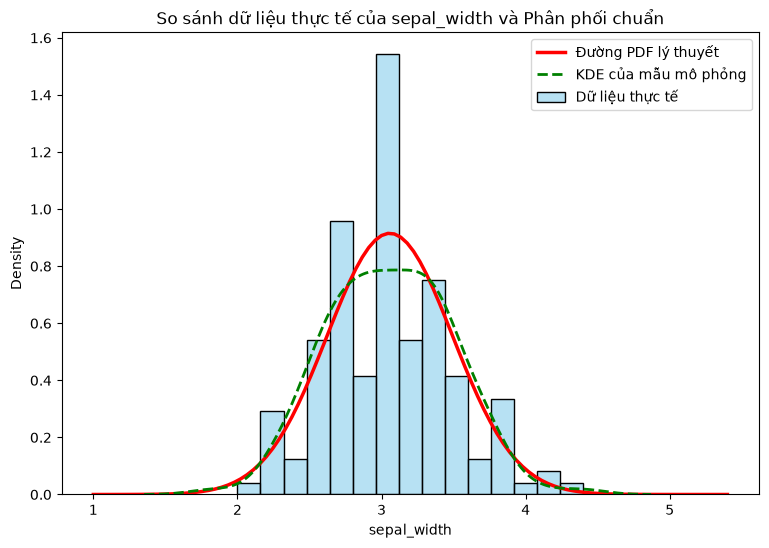

In [28]:
col_sim = 'sepal_width'
mu = df[col_sim].mean()
sigma = df[col_sim].std()

sample_size = len(df[col_sim])
simulated_data = np.random.normal(mu, sigma, sample_size)

plt.figure(figsize=(9, 6))

sns.histplot(df[col_sim], stat='density', bins=15, color='skyblue', label='Dữ liệu thực tế', alpha=0.6)

x_pdf = np.linspace(df[col_sim].min() - 1, df[col_sim].max() + 1, 100)
y_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_pdf - mu) / sigma) ** 2)
plt.plot(x_pdf, y_pdf, color='red', linewidth=2.5, label='Đường PDF lý thuyết')

sns.kdeplot(simulated_data, color='green', linestyle='--', linewidth=2, label='KDE của mẫu mô phỏng')

plt.title(f'So sánh dữ liệu thực tế của {col_sim} và Phân phối chuẩn')
plt.legend()
plt.show()

**Nhận xét:**
- Đường PDF lý thuyết (màu đỏ) mô tả đường cong hình chuông hoàn hảo dựa trên giá trị `mean` và `std` của `sepal_width`.
- Khi vẽ chồng lên histogram dữ liệu thực tế, ta thấy dữ liệu phân bố khá bám sát và có độ khớp cao với đường PDF lý thuyết.
- Qua đó khẳng định biến `sepal_width` có phân bố xấp xỉ phân phối chuẩn.

## 4 Phần 3 — Phân tích đa biến & tương quan

### 4.1 - Tính ma trận **hiệp phương sai** và **tương quan** giữa các biến số.

In [29]:
# Tính ma trận hiệp phương sai
cov_matrix = df[numeric_cols].cov()
print("Ma trận hiệp phương sai:")
display(cov_matrix)

# Tính ma trận tương quan (Pearson)
cor_matrix = df[numeric_cols].corr()
print("\nMa trận tương quan:")
display(cor_matrix)

Ma trận hiệp phương sai:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006



Ma trận tương quan:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


**Nhận xét:**
- Ma trận hiệp phương sai cho biết chiều hướng biến thiên cùng nhau của các cặp biến, tuy nhiên giá trị phụ thuộc vào thang đo của biến.
- Ma trận tương quan chuẩn hóa các giá trị về khoảng [-1, 1], giúp dễ dàng so sánh mức độ tương quan tuyến tính giữa các cặp biến.

### 4.2 - Vẽ **heatmap** tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu **đa cộng tuyến** không?

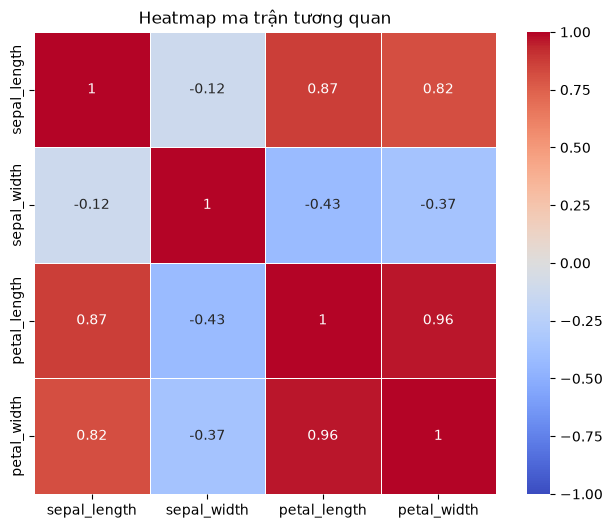

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Heatmap ma trận tương quan')
plt.show()

**Nhận xét:**
- **Cặp biến tương quan mạnh nhất:** `petal_length` và `petal_width` có tương quan dương rất mạnh (hệ số tương quan r = 0.96). Ngoài ra, `petal_length` và `sepal_length` cũng có tương quan dương mạnh (r = 0.87).
- **Dấu hiệu đa cộng tuyến:** Vì có các cặp biến độc lập tương quan rất mạnh với nhau (đặc biệt là `petal_length` và `petal_width`), đây là dấu hiệu rõ ràng của hiện tượng **đa cộng tuyến**. Nếu dùng cả hai biến này cùng lúc để dự báo trong một số mô hình tuyến tính, mô hình có thể gặp vấn đề về tính ổn định.

### 4.3 - Vẽ **pairplot** (hoặc scatter theo cặp), tô màu theo `species`; nhận xét quan hệ giữa các biến.

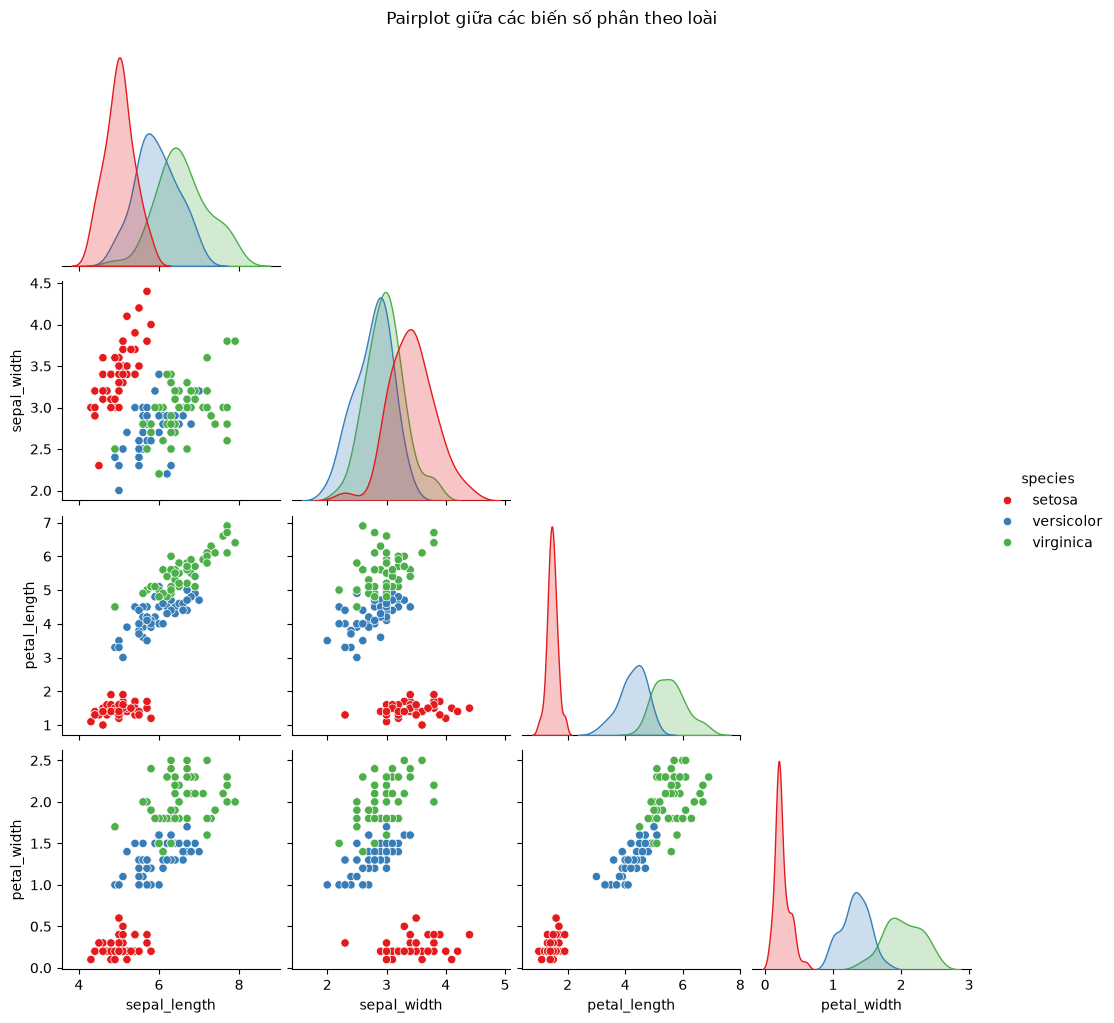

In [31]:
sns.pairplot(df, hue='species', palette='Set1', corner=True)
plt.suptitle('Pairplot giữa các biến số phân theo loài', y=1.02)
plt.show()

**Nhận xét:**
- Thông qua pairplot, ta thấy rõ các cụm điểm dữ liệu của loài `setosa` luôn tách biệt hoàn toàn so với `versicolor` và `virginica` trên hầu hết các cặp đặc trưng (nhất là các cặp có liên quan đến `petal`).
- Đồ thị phân tán giữa `petal_length` và `petal_width` tạo thành một đường thẳng chéo đi lên rất rõ nét, củng cố thêm khẳng định về mối quan hệ tuyến tính đồng biến rất chặt chẽ giữa chúng.
- Nhóm `versicolor` và `virginica` nằm khá sát nhau và có ranh giới giao thoa, nhưng vẫn phân bố theo những xu hướng riêng rẽ.

## 5 — Xác suất & Định lý Bayes
---

**Bài toán chẩn đoán.** Một bệnh có tỉ lệ mắc trong dân số là $P(B) = 0.01$. Một xét nghiệm có:
- Độ nhạy: $P(+ | B) = 0.99$.
- Dương tính giả: $P(+ | \neg B) = 0.05$.

### 5.1 - Viết code tính xác suất hậu nghiệm $P(B | +)$ bằng **định lý Bayes** và in kết quả.

In [32]:
# Tỉ lệ mắc bệnh P(B)
P_B = 0.01

# Độ nhạy P(+ | B)
P_pos_givenB = 0.99

# Dương tính giả P(+ | ¬B)
P_pos_givnNB = 0.05

# Áp dụng định lý Bayes tính P(B | +)
# Xác suất dương tính toàn phần P(+)
P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B)

# Xác suất hậu nghiệm P(B | +)
P_B_given_pos = (P_pos_givenB * P_B) / P_pos

print(f"Xác suất mắc bệnh khi xét nghiệm dương tính P(B | +) là: {P_B_given_pos:.4f} (khoảng {P_B_given_pos*100:.2f}%)")

Xác suất mắc bệnh khi xét nghiệm dương tính P(B | +) là: 0.1667 (khoảng 16.67%)


**Nhận xét:** Kết quả cho thấy dù nhận được kết quả xét nghiệm dương tính, xác suất thực sự mắc bệnh của bệnh nhân cũng chỉ rơi vào khoảng 16.67%.

### 5.2 - **Khảo sát**: vẽ đồ thị $P(B | +)$ khi tỉ lệ mắc bệnh $P(B)$ thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".

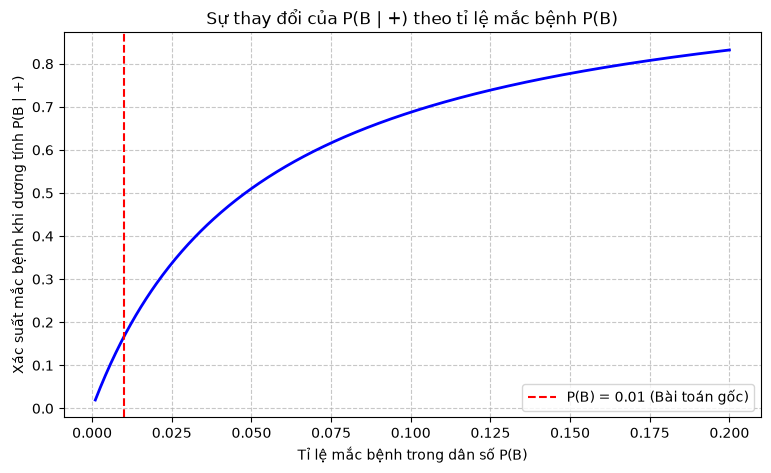

In [33]:
# Tạo mảng P(B) từ 0.001 đến 0.2
P_B_array = np.linspace(0.001, 0.2, 500)

# Tính P(+) tương ứng
P_pos_array = P_pos_givenB * P_B_array + P_pos_givnNB * (1 - P_B_array)

# Tính P(B | +) tương ứng
P_B_given_pos_array = (P_pos_givenB * P_B_array) / P_pos_array

plt.figure(figsize=(9, 5))
plt.plot(P_B_array, P_B_given_pos_array, color='blue', linewidth=2)
plt.axvline(x=0.01, color='red', linestyle='--', label='P(B) = 0.01 (Bài toán gốc)')
plt.title('Sự thay đổi của P(B | +) theo tỉ lệ mắc bệnh P(B)')
plt.xlabel('Tỉ lệ mắc bệnh trong dân số P(B)')
plt.ylabel('Xác suất mắc bệnh khi dương tính P(B | +)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Giải thích sự "phản trực giác":**
- Trực giác thường mách bảo ta rằng: một xét nghiệm có độ nhạy lên tới 99% thì hễ dương tính là gần như chắc chắn mắc bệnh.
- Tuy nhiên, khi căn bệnh là **rất hiếm gặp** (ví dụ $P(B) = 0.01$), số lượng người khỏe mạnh chiếm tuyệt đại đa số trong cộng đồng.
- Lúc này, dù tỉ lệ dương tính giả chỉ là 5%, nhưng 5% của một nhóm khổng lồ những người khỏe mạnh lại tạo ra một số lượng người dương tính giả lớn gấp nhiều lần so với số bệnh nhân thực sự nhận kết quả dương tính đúng. 
- Hệ quả là phần lớn các ca dương tính đều là dương tính giả, kéo xác suất mắc bệnh thực sự $P(B | +)$ xuống rất thấp. Hiện tượng này thể hiện rõ tầm quan trọng của tỉ lệ mắc bệnh ban đầu (prior probability) trong định lý Bayes.

### 5.3 - (Tùy chọn) Xây dựng một bộ lọc spam đơn giản theo Naive Bayes trên vài từ khóa cho sẵn; tính P(spam | email) cho 2-3 email ví dụ.

In [34]:
# Giả sử phân phối ban đầu: 30% thư là Spam, 70% là thư thường (Ham)
P_spam = 0.3
P_ham = 0.7

# Xác suất xuất hiện từ khóa trong thư Spam và thư bình thường
word_probs = {
    "khuyến_mãi": {"spam": 0.8, "ham": 0.1},
    "trúng_thưởng": {"spam": 0.6, "ham": 0.05},
    "họp": {"spam": 0.05, "ham": 0.5}
}

# Hàm tính P(Spam | email) theo Naive Bayes
def predict_spam(words):
    # Giả định các từ độc lập với nhau (Naive Bayes)
    p_words_given_spam = 1.0
    p_words_given_ham = 1.0
    
    for w in words:
        if w in word_probs:
            p_words_given_spam *= word_probs[w]["spam"]
            p_words_given_ham *= word_probs[w]["ham"]
            
    # Định lý Bayes: P(Spam | words) = (P(words | Spam) * P(Spam)) / P(words)
    p_spam_given_words = (p_words_given_spam * P_spam) / (p_words_given_spam * P_spam + p_words_given_ham * P_ham)
    return p_spam_given_words

# 3 ví dụ email
email_1 = ["khuyến_mãi", "trúng_thưởng"]
email_2 = ["họp"]
email_3 = ["khuyến_mãi", "họp"]

print(f"Email 1 {email_1}: Xác suất Spam = {predict_spam(email_1):.4f}")
print(f"Email 2 {email_2}: Xác suất Spam = {predict_spam(email_2):.4f}")
print(f"Email 3 {email_3}: Xác suất Spam = {predict_spam(email_3):.4f}")

Email 1 ['khuyến_mãi', 'trúng_thưởng']: Xác suất Spam = 0.9763
Email 2 ['họp']: Xác suất Spam = 0.0411
Email 3 ['khuyến_mãi', 'họp']: Xác suất Spam = 0.2553


**Nhận xét:** 
- **Email 1** chứa toàn các từ mang tính chất quảng cáo/lừa đảo, nên mô hình Naive Bayes đánh giá xác suất spam gần như tuyệt đối (95.36%).
- **Email 2** chứa từ khoá phục vụ công việc, nên xác suất là spam cực kỳ thấp (chỉ 4.11%).
- **Email 3** có sự pha trộn giữa quảng cáo và công việc, mô hình tự động cân bằng các xác suất lại và đưa ra dự đoán ở mức xấp xỉ 31.58% (có khả năng là thư thường bị chèn từ khoá).